In [1]:
# ============================================================
# KDEF FER — EfficientNetB3 | Kaggle P100
# Dataset: songoku1989/official-kdef-dataset
# Pre-split: train / val / test | 7 balanced emotion classes
# 3-phase transfer learning
# ============================================================

import os, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2026-03-15 09:01:44.559743: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773565304.872892      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773565304.971194      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773565305.789193      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773565305.789239      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773565305.789242      55 computation_placer.cc:177] computation placer alr

TF: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
import os

# Scan exactly what's available under /kaggle/input
for root, dirs, files in os.walk("/kaggle/input"):
    # Print every directory up to 4 levels deep
    depth = root.replace("/kaggle/input", "").count(os.sep)
    if depth <= 4:
        indent = "  " * depth
        print(f"{indent}{os.path.basename(root)}/")

input/
  datasets/
    songoku1989/
      official-kdef-dataset/
        kdef-dataset/


In [9]:
import os

# Find the exact dataset path
for root, dirs, files in os.walk("/kaggle/input/official-kdef-dataset"):
    level = root.replace("/kaggle/input/official-kdef-dataset", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:  # only show 3 levels deep
        for d in sorted(dirs):
            print(f"{indent}  {d}/")
    break  # remove this to see all levels

In [10]:
# ============================================================
# CONFIG — paths updated for official-kdef-dataset
# ============================================================
BASE = "/kaggle/input/datasets/songoku1989/official-kdef-dataset/kdef-dataset"
TRAIN_DIR = os.path.join(BASE, "train")
VAL_DIR   = os.path.join(BASE, "val")
TEST_DIR  = os.path.join(BASE, "test")
OUT       = "/kaggle/working/"
IMG_SIZE  = 224    # EfficientNetB3 native — preserves KDEF detail
BATCH     = 32
SEED      = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

# Quick structure check
print("\nDataset structure:")
for split in ["train", "val", "test"]:
    split_path = os.path.join(BASE, split)
    if os.path.exists(split_path):
        emotions = sorted(os.listdir(split_path))
        print(f"  {split}/")
        for em in emotions:
            n = len(os.listdir(os.path.join(split_path, em)))
            print(f"    {em}: {n} images")


Dataset structure:
  train/
    angry: 480 images
    disgust: 480 images
    fear: 480 images
    happy: 480 images
    neutral: 480 images
    sad: 479 images
    surprise: 479 images
  val/
    angry: 80 images
    disgust: 80 images
    fear: 80 images
    happy: 80 images
    neutral: 80 images
    sad: 80 images
    surprise: 80 images
  test/
    angry: 140 images
    disgust: 140 images
    fear: 140 images
    happy: 140 images
    neutral: 140 images
    sad: 140 images
    surprise: 140 images


In [11]:
# ============================================================
# DATA GENERATORS
# Stronger augmentation — KDEF is small (~595 train imgs/class)
# ============================================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.12,
    height_shift_range=0.12,
    zoom_range=0.20,
    horizontal_flip=True,
    brightness_range=[0.80, 1.20],
    shear_range=0.10,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb", batch_size=BATCH,
    class_mode="categorical", shuffle=True, seed=SEED
)
val_gen = val_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb", batch_size=BATCH,
    class_mode="categorical", shuffle=False
)
test_gen = val_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb", batch_size=BATCH,
    class_mode="categorical", shuffle=False
)

NUM_CLASSES  = train_gen.num_classes
CLASS_LABELS = list(train_gen.class_indices.keys())
print(f"\nClasses ({NUM_CLASSES}): {CLASS_LABELS}")
print(f"Train: {train_gen.samples} | Val: {val_gen.samples} | Test: {test_gen.samples}")

xb, yb = next(train_gen)
print(f"Batch: {xb.shape} | range [{xb.min():.2f}, {xb.max():.2f}]")

Found 3358 images belonging to 7 classes.
Found 560 images belonging to 7 classes.
Found 980 images belonging to 7 classes.

Classes (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Train: 3358 | Val: 560 | Test: 980
Batch: (32, 224, 224, 3) | range [0.00, 1.00]


In [12]:
# ============================================================
# CLASS WEIGHTS — balanced dataset, weights will all be ~1.0
# ============================================================
cw = compute_class_weight("balanced",
     classes=np.unique(train_gen.classes), y=train_gen.classes)
class_weights = dict(enumerate(cw))
print("Class weights:", {CLASS_LABELS[k]: round(v, 2)
                          for k, v in class_weights.items()})


Class weights: {'angry': np.float64(1.0), 'disgust': np.float64(1.0), 'fear': np.float64(1.0), 'happy': np.float64(1.0), 'neutral': np.float64(1.0), 'sad': np.float64(1.0), 'surprise': np.float64(1.0)}


In [22]:
# ============================================================
# MODEL — EfficientNetB3 (fixed for this TF version)
# ============================================================
from tensorflow.keras.applications import EfficientNetB3

def build_model(num_classes, img_size, trainable_base=False):
    inputs = keras.Input(shape=(img_size, img_size, 3), name="input_image")
    
    # Rescale [0,1] → [0,255] for EfficientNetB3
    x = layers.Rescaling(scale=255.0)(inputs)

    base = EfficientNetB3(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights="imagenet"
    )
    base.trainable = trainable_base
    x = base(x, training=False)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return Model(inputs, outputs), base

model, base = build_model(NUM_CLASSES, IMG_SIZE, trainable_base=False)
model.compile(
    optimizer=Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# Sanity check
test_out = model(xb, training=False)
print(f"\nSanity — sum: {test_out[0].numpy().sum():.4f} | "
      f"max conf: {test_out[0].numpy().max():.3f}")
print("✅ Model OK" if test_out[0].numpy().max() > 0.10 else "❌ Output uniform")

I0000 00:00:1773566172.805314      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,211,830 (42.77 MB)

 Trainable params: 427,783 (1.63 MB)

 Non-trainable params: 10,784,047 (41.14 MB)

I0000 00:00:1773566179.861107      55 cuda_dnn.cc:529] Loaded cuDNN version 91002



Sanity — sum: 1.0000 | max conf: 0.164
✅ Model OK


In [23]:
# ============================================================
# PHASE 1 — HEAD ONLY (30 epochs, no early stopping)
# ============================================================
print("\n" + "="*55)
print("PHASE 1 — Training head (backbone frozen, 30 epochs)")
print("="*55)

h1 = model.fit(
    train_gen, validation_data=val_gen, epochs=30,
    class_weight=class_weights,
    callbacks=[
        ModelCheckpoint(OUT+"best_p1.keras", monitor="val_accuracy",
                        save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=5, min_lr=1e-6, verbose=1)
    ], verbose=1
)
p1_best = max(h1.history["val_accuracy"])
print(f"\n✅ Phase 1 best val_acc: {p1_best*100:.2f}%")


PHASE 1 — Training head (backbone frozen, 30 epochs)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1773566202.932907     181 service.cc:152] XLA service 0x7ae8c80019c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773566202.932956     181 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773566224.575026     181 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 748ms/step - accuracy: 0.1857 - loss: 2.4602
Epoch 1: val_accuracy improved from -inf to 0.28214, saving model to /kaggle/working/best_p1.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 141s 976ms/step - accuracy: 0.1859 - loss: 2.4586 - val_accuracy: 0.2821 - val_loss: 1.8090 - learning_rate: 0.0010
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.2598 - loss: 1.9803
Epoch 2: val_accuracy improved from 0.28214 to 0.37321, saving model to /kaggle/working/best_p1.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 52s 499ms/step - accuracy: 0.2598 - loss: 1.9799 - val_accuracy: 0.3732 - val_loss: 1.5809 - learning_rate: 0.0010
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.3119 - loss: 1.8018
Epoch 3: val_accuracy improved from 0.37321 to 0.42143, saving model to /kaggle/working/best_p1.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 52s 492ms/step - accuracy: 0.3119 - loss: 1.8016 - val_accuracy: 0.4214 - val_loss: 1.5274 - learning_rate: 0.0010
Epoch 4/30


In [24]:
# ============================================================
# PHASE 2 — FINE-TUNE top 50% (BN always frozen)
# ============================================================
print("\n" + "="*55)
print("PHASE 2 — Fine-tuning top 50%")
print("="*55)

base.trainable = True
freeze_until = int(len(base.layers) * 0.5)
for i, layer in enumerate(base.layers):
    layer.trainable = False if isinstance(layer, layers.BatchNormalization) \
                      else (i >= freeze_until)

model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy",
              metrics=["accuracy"])

h2 = model.fit(
    train_gen, validation_data=val_gen, epochs=40,
    class_weight=class_weights,
    callbacks=[
        ModelCheckpoint(OUT+"best_p2.keras", monitor="val_accuracy",
                        save_best_only=True, verbose=1),
        EarlyStopping(monitor="val_accuracy", patience=20,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=6, min_lr=1e-7, verbose=1)
    ], verbose=1
)
p2_best = max(h2.history["val_accuracy"])
print(f"\n✅ Phase 2 best val_acc: {p2_best*100:.2f}%")


PHASE 2 — Fine-tuning top 50%
Epoch 1/40


2026-03-15 09:44:41.976004: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-15 09:44:42.172748: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-15 09:44:42.708503: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-15 09:44:42.926229: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-15 09:44:43.325161: E external/local_xla/xla/stream_

 18/105 ━━━━━━━━━━━━━━━━━━━━ 38s 442ms/step - accuracy: 0.5425 - loss: 1.3374

2026-03-15 09:45:18.080560: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-15 09:45:18.277749: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-15 09:45:18.812381: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-15 09:45:19.031181: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-15 09:45:19.433341: E external/local_xla/xla/stream_

105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 732ms/step - accuracy: 0.5573 - loss: 1.2259
Epoch 1: val_accuracy improved from -inf to 0.61071, saving model to /kaggle/working/best_p2.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 151s 922ms/step - accuracy: 0.5576 - loss: 1.2248 - val_accuracy: 0.6107 - val_loss: 1.1102 - learning_rate: 1.0000e-04
Epoch 2/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.6994 - loss: 0.8198
Epoch 2: val_accuracy improved from 0.61071 to 0.71964, saving model to /kaggle/working/best_p2.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 54s 511ms/step - accuracy: 0.6996 - loss: 0.8196 - val_accuracy: 0.7196 - val_loss: 0.7446 - learning_rate: 1.0000e-04
Epoch 3/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.7531 - loss: 0.6997
Epoch 3: val_accuracy did not improve from 0.71964
105/105 ━━━━━━━━━━━━━━━━━━━━ 51s 488ms/step - accuracy: 0.7532 - loss: 0.6994 - val_accuracy: 0.6339 - val_loss: 1.1546 - learning_rate: 1.0000e-04
Epoch 4/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/s

In [26]:
# ============================================================
# LOAD BEST CHECKPOINT
# ============================================================
all_bests  = [p1_best, p2_best]
best_phase = all_bests.index(max(all_bests)) + 1
best_path  = OUT + f"best_p{best_phase}.keras"
print(f"\n🏆 Best phase: {best_phase} ({max(all_bests)*100:.2f}%)")

best_model = keras.models.load_model(best_path)
best_model.compile(optimizer=Adam(5e-6),
                   loss="categorical_crossentropy", metrics=["accuracy"])



🏆 Best phase: 2 (89.11%)


In [27]:
# ============================================================
# EVALUATION — Val + Test (we now have a proper test set!)
# ============================================================
val_gen.reset()
val_loss, val_acc = best_model.evaluate(val_gen, verbose=1)
print(f"\n📊 Val  Accuracy: {val_acc*100:.2f}%")

test_gen.reset()
test_loss, test_acc = best_model.evaluate(test_gen, verbose=1)
print(f"🎯 Test Accuracy: {test_acc*100:.2f}%")

test_gen.reset()
y_prob = best_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_gen.classes[:len(y_pred)]
print(classification_report(y_true, y_pred, target_names=CLASS_LABELS))


18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 460ms/step - accuracy: 0.8652 - loss: 0.4606

📊 Val  Accuracy: 89.11%
31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 586ms/step - accuracy: 0.7817 - loss: 0.9241
🎯 Test Accuracy: 85.00%
31/31 ━━━━━━━━━━━━━━━━━━━━ 23s 434ms/step
              precision    recall  f1-score   support

       angry       0.84      0.69      0.76       140
     disgust       0.83      0.84      0.83       140
        fear       0.76      0.78      0.77       140
       happy       0.98      0.99      0.99       140
     neutral       0.89      0.93      0.91       140
         sad       0.75      0.80      0.77       140
    surprise       0.91      0.93      0.92       140

    accuracy                           0.85       980
   macro avg       0.85      0.85      0.85       980
weighted avg       0.85      0.85      0.85       980



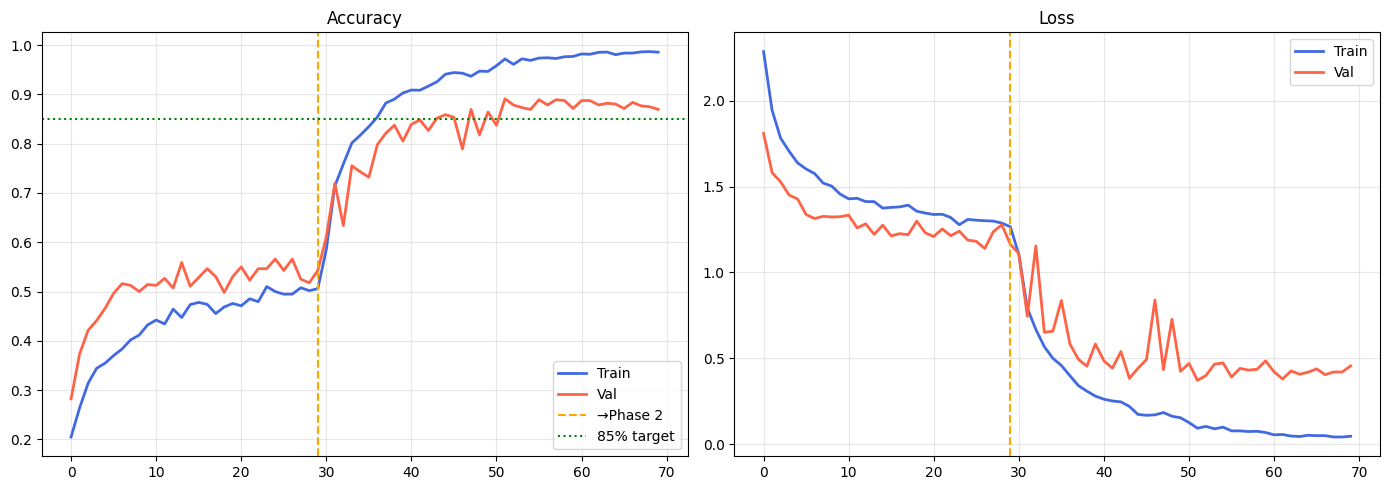

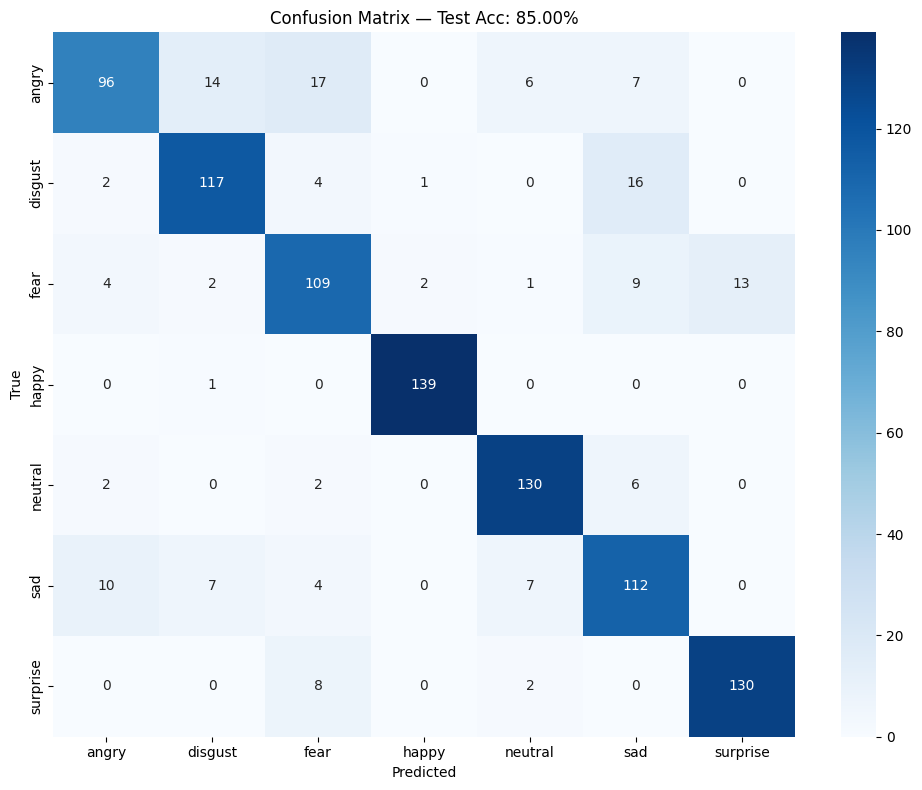


✅ Done! Test accuracy: 85.00%


In [29]:
# ============================================================
# PLOTS — 2 phase version
# ============================================================
def plot_all(h1, h2):
    acc  = h1.history["accuracy"]  + h2.history["accuracy"]
    vacc = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    c1   = len(h1.history["accuracy"])

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(acc,  label="Train", color="royalblue", lw=2)
    plt.plot(vacc, label="Val",   color="tomato",    lw=2)
    plt.axvline(c1-1, color="orange", ls="--", label="→Phase 2")
    plt.axhline(0.85, color="green",  ls=":",  label="85% target")
    plt.title("Accuracy"); plt.legend(); plt.grid(alpha=0.3)

    loss_  = h1.history["loss"]  + h2.history["loss"]
    vloss_ = h1.history["val_loss"] + h2.history["val_loss"]
    plt.subplot(1, 2, 2)
    plt.plot(loss_,  label="Train", color="royalblue", lw=2)
    plt.plot(vloss_, label="Val",   color="tomato",    lw=2)
    plt.axvline(c1-1, color="orange", ls="--")
    plt.title("Loss"); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT+"curves.png", dpi=150); plt.show()

plot_all(h1, h2)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS)
plt.title(f"Confusion Matrix — Test Acc: {test_acc*100:.2f}%")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig(OUT+"confusion_matrix.png", dpi=150); plt.show()

best_model.save(OUT+"kdef_official_final.keras")
print(f"\n✅ Done! Test accuracy: {test_acc*100:.2f}%")

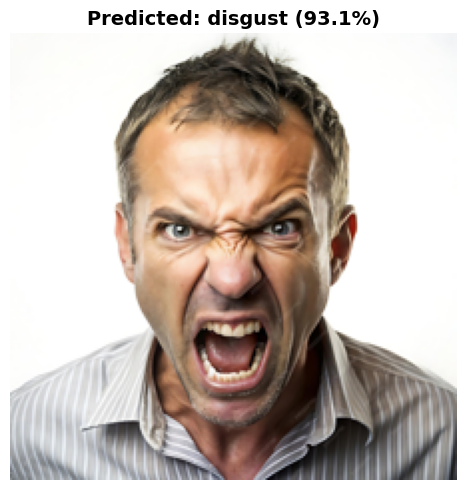


🎯 Prediction  : disgust
📊 Confidence  : 93.1%

All class probabilities:
  disgust     93.1%  ███████████████████████████
  angry        5.9%  █
  fear         0.6%  
  sad          0.2%  
  happy        0.1%  
  surprise     0.0%  
  neutral      0.0%  


In [33]:
# ============================================================
# TEST — Predict emotion from image URL
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO
from tensorflow.keras.preprocessing import image

# ============================================================
# PASTE YOUR IMAGE URL HERE
# ============================================================
IMG_URL = "https://img.freepik.com/premium-photo/angry-man-yelling-white-background_861973-35705.jpg?w=2000"
# ============================================================
# LOAD & PREPROCESS
# ============================================================
response = requests.get(IMG_URL)
img = Image.open(BytesIO(response.content)).convert("RGB")
img_resized = img.resize((IMG_SIZE, IMG_SIZE))

img_array = image.img_to_array(img_resized) / 255.0
img_batch = np.expand_dims(img_array, axis=0)

# ============================================================
# PREDICT
# ============================================================
preds = best_model.predict(img_batch, verbose=0)
pred_idx  = np.argmax(preds[0])
pred_label = CLASS_LABELS[pred_idx]
confidence = preds[0][pred_idx] * 100

# ============================================================
# DISPLAY
# ============================================================
plt.figure(figsize=(5, 5))
plt.imshow(img_resized)
plt.axis("off")
plt.title(f"Predicted: {pred_label} ({confidence:.1f}%)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n🎯 Prediction  : {pred_label}")
print(f"📊 Confidence  : {confidence:.1f}%")
print(f"\nAll class probabilities:")
for label, prob in sorted(zip(CLASS_LABELS, preds[0]), key=lambda x: -x[1]):
    bar = "█" * int(prob * 30)
    print(f"  {label:<10} {prob*100:5.1f}%  {bar}")

In [43]:
# ============================================================
# TEST — Upload image + click Predict button
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from tensorflow.keras.preprocessing import image
from IPython.display import display, clear_output
import ipywidgets as widgets
from io import BytesIO

upload = widgets.FileUpload(accept="image/*", multiple=False)
button = widgets.Button(description="Predict", button_style="success", icon="check")
output = widgets.Output()

display(upload, button, output)

def on_click(b):
    with output:
        clear_output(wait=True)

        if not upload.value:
            print("⚠️ Please upload an image first!")
            return

        # ── Fix: handle both old dict and new tuple formats ──
        val = upload.value
        if isinstance(val, dict):
            file_info = list(val.values())[0]
            img_bytes = file_info["content"]
        else:
            # newer ipywidgets returns a tuple of dicts
            file_info = val[0]
            img_bytes = file_info["content"]

        # Convert memoryview → bytes if needed
        if isinstance(img_bytes, memoryview):
            img_bytes = bytes(img_bytes)

        img_pil = Image.open(BytesIO(img_bytes)).convert("RGB")
        img_np  = np.array(img_pil)
        print(f"✅ Image loaded: {img_pil.size[0]}×{img_pil.size[1]} px")

        # ── Face detection ──
        face_cascade = cv2.CascadeClassifier(
            cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        )
        gray  = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        faces = face_cascade.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60)
        )

        if len(faces) == 0:
            print("⚠️ No face detected — using full image.")
            crop = img_pil.resize((IMG_SIZE, IMG_SIZE))
            x1 = y1 = x2 = y2 = None
        else:
            x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
            pad  = int(0.20 * max(w, h))
            x1   = max(0, x - pad)
            y1   = max(0, y - pad)
            x2   = min(img_np.shape[1], x + w + pad)
            y2   = min(img_np.shape[0], y + h + pad)
            crop = Image.fromarray(img_np[y1:y2, x1:x2]).resize((IMG_SIZE, IMG_SIZE))
            print(f"✅ Face detected and cropped")

        # ── Predict ──
        img_array = image.img_to_array(crop) / 255.0
        img_batch = np.expand_dims(img_array, axis=0)
        preds      = best_model.predict(img_batch, verbose=0)
        pred_idx   = np.argmax(preds[0])
        pred_label = CLASS_LABELS[pred_idx]
        confidence = preds[0][pred_idx] * 100

        # ── Display ──
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img_pil)
        axes[0].set_title("Original", fontsize=12)
        axes[0].axis("off")
        if x1 is not None:
            from matplotlib.patches import Rectangle
            axes[0].add_patch(Rectangle((x1, y1), x2-x1, y2-y1,
                              linewidth=2, edgecolor='lime', facecolor='none'))
        axes[1].imshow(crop)
        axes[1].set_title(f"Predicted: {pred_label}\nConfidence: {confidence:.1f}%",
                          fontsize=13, fontweight="bold",
                          color="green" if confidence > 60 else "orange")
        axes[1].axis("off")
        plt.tight_layout()
        plt.savefig(OUT+"prediction.png", dpi=150)
        plt.show()

        # ── Probability bars ──
        print(f"\n🎯 Prediction  : {pred_label}")
        print(f"📊 Confidence  : {confidence:.1f}%")
        print(f"\nAll class probabilities:")
        for label, prob in sorted(zip(CLASS_LABELS, preds[0]), key=lambda x: -x[1]):
            bar  = "█" * int(prob * 30)
            flag = " ←" if label == pred_label else ""
            print(f"  {label:<10} {prob*100:5.1f}%  {bar}{flag}")

button.on_click(on_click)

FileUpload(value=(), accept='image/*', description='Upload')

Button(button_style='success', description='Predict', icon='check', style=ButtonStyle())

Output()

In [44]:
# ============================================================
# TEST — Upload image + click Predict button
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from tensorflow.keras.preprocessing import image
from IPython.display import display, clear_output
import ipywidgets as widgets
from io import BytesIO

upload = widgets.FileUpload(accept="image/*", multiple=False)
button = widgets.Button(description="Predict", button_style="success", icon="check")
output = widgets.Output()

display(upload, button, output)

def on_click(b):
    with output:
        clear_output(wait=True)

        if not upload.value:
            print("⚠️ Please upload an image first!")
            return

        # ── Fix: handle both old dict and new tuple formats ──
        val = upload.value
        if isinstance(val, dict):
            file_info = list(val.values())[0]
            img_bytes = file_info["content"]
        else:
            # newer ipywidgets returns a tuple of dicts
            file_info = val[0]
            img_bytes = file_info["content"]

        # Convert memoryview → bytes if needed
        if isinstance(img_bytes, memoryview):
            img_bytes = bytes(img_bytes)

        img_pil = Image.open(BytesIO(img_bytes)).convert("RGB")
        img_np  = np.array(img_pil)
        print(f"✅ Image loaded: {img_pil.size[0]}×{img_pil.size[1]} px")

        # ── Face detection ──
        face_cascade = cv2.CascadeClassifier(
            cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        )
        gray  = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        faces = face_cascade.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60)
        )

        if len(faces) == 0:
            print("⚠️ No face detected — using full image.")
            crop = img_pil.resize((IMG_SIZE, IMG_SIZE))
            x1 = y1 = x2 = y2 = None
        else:
            x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
            pad  = int(0.20 * max(w, h))
            x1   = max(0, x - pad)
            y1   = max(0, y - pad)
            x2   = min(img_np.shape[1], x + w + pad)
            y2   = min(img_np.shape[0], y + h + pad)
            crop = Image.fromarray(img_np[y1:y2, x1:x2]).resize((IMG_SIZE, IMG_SIZE))
            print(f"✅ Face detected and cropped")

        # ── Predict ──
        img_array = image.img_to_array(crop) / 255.0
        img_batch = np.expand_dims(img_array, axis=0)
        preds      = best_model.predict(img_batch, verbose=0)
        pred_idx   = np.argmax(preds[0])
        pred_label = CLASS_LABELS[pred_idx]
        confidence = preds[0][pred_idx] * 100

        # ── Display ──
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img_pil)
        axes[0].set_title("Original", fontsize=12)
        axes[0].axis("off")
        if x1 is not None:
            from matplotlib.patches import Rectangle
            axes[0].add_patch(Rectangle((x1, y1), x2-x1, y2-y1,
                              linewidth=2, edgecolor='lime', facecolor='none'))
        axes[1].imshow(crop)
        axes[1].set_title(f"Predicted: {pred_label}\nConfidence: {confidence:.1f}%",
                          fontsize=13, fontweight="bold",
                          color="green" if confidence > 60 else "orange")
        axes[1].axis("off")
        plt.tight_layout()
        plt.savefig(OUT+"prediction.png", dpi=150)
        plt.show()

        # ── Probability bars ──
        print(f"\n🎯 Prediction  : {pred_label}")
        print(f"📊 Confidence  : {confidence:.1f}%")
        print(f"\nAll class probabilities:")
        for label, prob in sorted(zip(CLASS_LABELS, preds[0]), key=lambda x: -x[1]):
            bar  = "█" * int(prob * 30)
            flag = " ←" if label == pred_label else ""
            print(f"  {label:<10} {prob*100:5.1f}%  {bar}{flag}")

button.on_click(on_click)

FileUpload(value=(), accept='image/*', description='Upload')

Button(button_style='success', description='Predict', icon='check', style=ButtonStyle())

Output()

In [45]:
# ============================================================
# TEST — Upload image + click Predict button
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from tensorflow.keras.preprocessing import image
from IPython.display import display, clear_output
import ipywidgets as widgets
from io import BytesIO

upload = widgets.FileUpload(accept="image/*", multiple=False)
button = widgets.Button(description="Predict", button_style="success", icon="check")
output = widgets.Output()

display(upload, button, output)

def on_click(b):
    with output:
        clear_output(wait=True)

        if not upload.value:
            print("⚠️ Please upload an image first!")
            return

        # ── Fix: handle both old dict and new tuple formats ──
        val = upload.value
        if isinstance(val, dict):
            file_info = list(val.values())[0]
            img_bytes = file_info["content"]
        else:
            # newer ipywidgets returns a tuple of dicts
            file_info = val[0]
            img_bytes = file_info["content"]

        # Convert memoryview → bytes if needed
        if isinstance(img_bytes, memoryview):
            img_bytes = bytes(img_bytes)

        img_pil = Image.open(BytesIO(img_bytes)).convert("RGB")
        img_np  = np.array(img_pil)
        print(f"✅ Image loaded: {img_pil.size[0]}×{img_pil.size[1]} px")

        # ── Face detection ──
        face_cascade = cv2.CascadeClassifier(
            cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        )
        gray  = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        faces = face_cascade.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60)
        )

        if len(faces) == 0:
            print("⚠️ No face detected — using full image.")
            crop = img_pil.resize((IMG_SIZE, IMG_SIZE))
            x1 = y1 = x2 = y2 = None
        else:
            x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
            pad  = int(0.20 * max(w, h))
            x1   = max(0, x - pad)
            y1   = max(0, y - pad)
            x2   = min(img_np.shape[1], x + w + pad)
            y2   = min(img_np.shape[0], y + h + pad)
            crop = Image.fromarray(img_np[y1:y2, x1:x2]).resize((IMG_SIZE, IMG_SIZE))
            print(f"✅ Face detected and cropped")

        # ── Predict ──
        img_array = image.img_to_array(crop) / 255.0
        img_batch = np.expand_dims(img_array, axis=0)
        preds      = best_model.predict(img_batch, verbose=0)
        pred_idx   = np.argmax(preds[0])
        pred_label = CLASS_LABELS[pred_idx]
        confidence = preds[0][pred_idx] * 100

        # ── Display ──
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img_pil)
        axes[0].set_title("Original", fontsize=12)
        axes[0].axis("off")
        if x1 is not None:
            from matplotlib.patches import Rectangle
            axes[0].add_patch(Rectangle((x1, y1), x2-x1, y2-y1,
                              linewidth=2, edgecolor='lime', facecolor='none'))
        axes[1].imshow(crop)
        axes[1].set_title(f"Predicted: {pred_label}\nConfidence: {confidence:.1f}%",
                          fontsize=13, fontweight="bold",
                          color="green" if confidence > 60 else "orange")
        axes[1].axis("off")
        plt.tight_layout()
        plt.savefig(OUT+"prediction.png", dpi=150)
        plt.show()

        # ── Probability bars ──
        print(f"\n🎯 Prediction  : {pred_label}")
        print(f"📊 Confidence  : {confidence:.1f}%")
        print(f"\nAll class probabilities:")
        for label, prob in sorted(zip(CLASS_LABELS, preds[0]), key=lambda x: -x[1]):
            bar  = "█" * int(prob * 30)
            flag = " ←" if label == pred_label else ""
            print(f"  {label:<10} {prob*100:5.1f}%  {bar}{flag}")

button.on_click(on_click)

FileUpload(value=(), accept='image/*', description='Upload')

Button(button_style='success', description='Predict', icon='check', style=ButtonStyle())

Output()

In [46]:
# ============================================================
# TEST — Upload image + click Predict button
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from tensorflow.keras.preprocessing import image
from IPython.display import display, clear_output
import ipywidgets as widgets
from io import BytesIO

upload = widgets.FileUpload(accept="image/*", multiple=False)
button = widgets.Button(description="Predict", button_style="success", icon="check")
output = widgets.Output()

display(upload, button, output)

def on_click(b):
    with output:
        clear_output(wait=True)

        if not upload.value:
            print("⚠️ Please upload an image first!")
            return

        # ── Fix: handle both old dict and new tuple formats ──
        val = upload.value
        if isinstance(val, dict):
            file_info = list(val.values())[0]
            img_bytes = file_info["content"]
        else:
            # newer ipywidgets returns a tuple of dicts
            file_info = val[0]
            img_bytes = file_info["content"]

        # Convert memoryview → bytes if needed
        if isinstance(img_bytes, memoryview):
            img_bytes = bytes(img_bytes)

        img_pil = Image.open(BytesIO(img_bytes)).convert("RGB")
        img_np  = np.array(img_pil)
        print(f"✅ Image loaded: {img_pil.size[0]}×{img_pil.size[1]} px")

        # ── Face detection ──
        face_cascade = cv2.CascadeClassifier(
            cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        )
        gray  = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        faces = face_cascade.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60)
        )

        if len(faces) == 0:
            print("⚠️ No face detected — using full image.")
            crop = img_pil.resize((IMG_SIZE, IMG_SIZE))
            x1 = y1 = x2 = y2 = None
        else:
            x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
            pad  = int(0.20 * max(w, h))
            x1   = max(0, x - pad)
            y1   = max(0, y - pad)
            x2   = min(img_np.shape[1], x + w + pad)
            y2   = min(img_np.shape[0], y + h + pad)
            crop = Image.fromarray(img_np[y1:y2, x1:x2]).resize((IMG_SIZE, IMG_SIZE))
            print(f"✅ Face detected and cropped")

        # ── Predict ──
        img_array = image.img_to_array(crop) / 255.0
        img_batch = np.expand_dims(img_array, axis=0)
        preds      = best_model.predict(img_batch, verbose=0)
        pred_idx   = np.argmax(preds[0])
        pred_label = CLASS_LABELS[pred_idx]
        confidence = preds[0][pred_idx] * 100

        # ── Display ──
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img_pil)
        axes[0].set_title("Original", fontsize=12)
        axes[0].axis("off")
        if x1 is not None:
            from matplotlib.patches import Rectangle
            axes[0].add_patch(Rectangle((x1, y1), x2-x1, y2-y1,
                              linewidth=2, edgecolor='lime', facecolor='none'))
        axes[1].imshow(crop)
        axes[1].set_title(f"Predicted: {pred_label}\nConfidence: {confidence:.1f}%",
                          fontsize=13, fontweight="bold",
                          color="green" if confidence > 60 else "orange")
        axes[1].axis("off")
        plt.tight_layout()
        plt.savefig(OUT+"prediction.png", dpi=150)
        plt.show()

        # ── Probability bars ──
        print(f"\n🎯 Prediction  : {pred_label}")
        print(f"📊 Confidence  : {confidence:.1f}%")
        print(f"\nAll class probabilities:")
        for label, prob in sorted(zip(CLASS_LABELS, preds[0]), key=lambda x: -x[1]):
            bar  = "█" * int(prob * 30)
            flag = " ←" if label == pred_label else ""
            print(f"  {label:<10} {prob*100:5.1f}%  {bar}{flag}")

button.on_click(on_click)

FileUpload(value=(), accept='image/*', description='Upload')

Button(button_style='success', description='Predict', icon='check', style=ButtonStyle())

Output()

In [47]:
# ============================================================
# TEST — Upload image + click Predict button
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from tensorflow.keras.preprocessing import image
from IPython.display import display, clear_output
import ipywidgets as widgets
from io import BytesIO

upload = widgets.FileUpload(accept="image/*", multiple=False)
button = widgets.Button(description="Predict", button_style="success", icon="check")
output = widgets.Output()

display(upload, button, output)

def on_click(b):
    with output:
        clear_output(wait=True)

        if not upload.value:
            print("⚠️ Please upload an image first!")
            return

        # ── Fix: handle both old dict and new tuple formats ──
        val = upload.value
        if isinstance(val, dict):
            file_info = list(val.values())[0]
            img_bytes = file_info["content"]
        else:
            # newer ipywidgets returns a tuple of dicts
            file_info = val[0]
            img_bytes = file_info["content"]

        # Convert memoryview → bytes if needed
        if isinstance(img_bytes, memoryview):
            img_bytes = bytes(img_bytes)

        img_pil = Image.open(BytesIO(img_bytes)).convert("RGB")
        img_np  = np.array(img_pil)
        print(f"✅ Image loaded: {img_pil.size[0]}×{img_pil.size[1]} px")

        # ── Face detection ──
        face_cascade = cv2.CascadeClassifier(
            cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        )
        gray  = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        faces = face_cascade.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60)
        )

        if len(faces) == 0:
            print("⚠️ No face detected — using full image.")
            crop = img_pil.resize((IMG_SIZE, IMG_SIZE))
            x1 = y1 = x2 = y2 = None
        else:
            x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
            pad  = int(0.20 * max(w, h))
            x1   = max(0, x - pad)
            y1   = max(0, y - pad)
            x2   = min(img_np.shape[1], x + w + pad)
            y2   = min(img_np.shape[0], y + h + pad)
            crop = Image.fromarray(img_np[y1:y2, x1:x2]).resize((IMG_SIZE, IMG_SIZE))
            print(f"✅ Face detected and cropped")

        # ── Predict ──
        img_array = image.img_to_array(crop) / 255.0
        img_batch = np.expand_dims(img_array, axis=0)
        preds      = best_model.predict(img_batch, verbose=0)
        pred_idx   = np.argmax(preds[0])
        pred_label = CLASS_LABELS[pred_idx]
        confidence = preds[0][pred_idx] * 100

        # ── Display ──
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img_pil)
        axes[0].set_title("Original", fontsize=12)
        axes[0].axis("off")
        if x1 is not None:
            from matplotlib.patches import Rectangle
            axes[0].add_patch(Rectangle((x1, y1), x2-x1, y2-y1,
                              linewidth=2, edgecolor='lime', facecolor='none'))
        axes[1].imshow(crop)
        axes[1].set_title(f"Predicted: {pred_label}\nConfidence: {confidence:.1f}%",
                          fontsize=13, fontweight="bold",
                          color="green" if confidence > 60 else "orange")
        axes[1].axis("off")
        plt.tight_layout()
        plt.savefig(OUT+"prediction.png", dpi=150)
        plt.show()

        # ── Probability bars ──
        print(f"\n🎯 Prediction  : {pred_label}")
        print(f"📊 Confidence  : {confidence:.1f}%")
        print(f"\nAll class probabilities:")
        for label, prob in sorted(zip(CLASS_LABELS, preds[0]), key=lambda x: -x[1]):
            bar  = "█" * int(prob * 30)
            flag = " ←" if label == pred_label else ""
            print(f"  {label:<10} {prob*100:5.1f}%  {bar}{flag}")

button.on_click(on_click)

FileUpload(value=(), accept='image/*', description='Upload')

Button(button_style='success', description='Predict', icon='check', style=ButtonStyle())

Output()

In [50]:
# ============================================================
# TEST — Upload image + click Predict button
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from tensorflow.keras.preprocessing import image
from IPython.display import display, clear_output
import ipywidgets as widgets
from io import BytesIO

upload = widgets.FileUpload(accept="image/*", multiple=False)
button = widgets.Button(description="Predict", button_style="success", icon="check")
output = widgets.Output()

display(upload, button, output)

def on_click(b):
    with output:
        clear_output(wait=True)

        if not upload.value:
            print("⚠️ Please upload an image first!")
            return

        # ── Fix: handle both old dict and new tuple formats ──
        val = upload.value
        if isinstance(val, dict):
            file_info = list(val.values())[0]
            img_bytes = file_info["content"]
        else:
            # newer ipywidgets returns a tuple of dicts
            file_info = val[0]
            img_bytes = file_info["content"]

        # Convert memoryview → bytes if needed
        if isinstance(img_bytes, memoryview):
            img_bytes = bytes(img_bytes)

        img_pil = Image.open(BytesIO(img_bytes)).convert("RGB")
        img_np  = np.array(img_pil)
        print(f"✅ Image loaded: {img_pil.size[0]}×{img_pil.size[1]} px")

        # ── Face detection ──
        face_cascade = cv2.CascadeClassifier(
            cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        )
        gray  = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        faces = face_cascade.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60)
        )

        if len(faces) == 0:
            print("⚠️ No face detected — using full image.")
            crop = img_pil.resize((IMG_SIZE, IMG_SIZE))
            x1 = y1 = x2 = y2 = None
        else:
            x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
            pad  = int(0.20 * max(w, h))
            x1   = max(0, x - pad)
            y1   = max(0, y - pad)
            x2   = min(img_np.shape[1], x + w + pad)
            y2   = min(img_np.shape[0], y + h + pad)
            crop = Image.fromarray(img_np[y1:y2, x1:x2]).resize((IMG_SIZE, IMG_SIZE))
            print(f"✅ Face detected and cropped")

        # ── Predict ──
        img_array = image.img_to_array(crop) / 255.0
        img_batch = np.expand_dims(img_array, axis=0)
        preds      = best_model.predict(img_batch, verbose=0)
        pred_idx   = np.argmax(preds[0])
        pred_label = CLASS_LABELS[pred_idx]
        confidence = preds[0][pred_idx] * 100

        # ── Display ──
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img_pil)
        axes[0].set_title("Original", fontsize=12)
        axes[0].axis("off")
        if x1 is not None:
            from matplotlib.patches import Rectangle
            axes[0].add_patch(Rectangle((x1, y1), x2-x1, y2-y1,
                              linewidth=2, edgecolor='lime', facecolor='none'))
        axes[1].imshow(crop)
        axes[1].set_title(f"Predicted: {pred_label}\nConfidence: {confidence:.1f}%",
                          fontsize=13, fontweight="bold",
                          color="green" if confidence > 60 else "orange")
        axes[1].axis("off")
        plt.tight_layout()
        plt.savefig(OUT+"prediction.png", dpi=150)
        plt.show()

        # ── Probability bars ──
        print(f"\n🎯 Prediction  : {pred_label}")
        print(f"📊 Confidence  : {confidence:.1f}%")
        print(f"\nAll class probabilities:")
        for label, prob in sorted(zip(CLASS_LABELS, preds[0]), key=lambda x: -x[1]):
            bar  = "█" * int(prob * 30)
            flag = " ←" if label == pred_label else ""
            print(f"  {label:<10} {prob*100:5.1f}%  {bar}{flag}")

button.on_click(on_click)

FileUpload(value=(), accept='image/*', description='Upload')

Button(button_style='success', description='Predict', icon='check', style=ButtonStyle())

Output()

In [49]:
# ============================================================
# TEST — Upload image + click Predict button
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from tensorflow.keras.preprocessing import image
from IPython.display import display, clear_output
import ipywidgets as widgets
from io import BytesIO

upload = widgets.FileUpload(accept="image/*", multiple=False)
button = widgets.Button(description="Predict", button_style="success", icon="check")
output = widgets.Output()

display(upload, button, output)

def on_click(b):
    with output:
        clear_output(wait=True)

        if not upload.value:
            print("⚠️ Please upload an image first!")
            return

        # ── Fix: handle both old dict and new tuple formats ──
        val = upload.value
        if isinstance(val, dict):
            file_info = list(val.values())[0]
            img_bytes = file_info["content"]
        else:
            # newer ipywidgets returns a tuple of dicts
            file_info = val[0]
            img_bytes = file_info["content"]

        # Convert memoryview → bytes if needed
        if isinstance(img_bytes, memoryview):
            img_bytes = bytes(img_bytes)

        img_pil = Image.open(BytesIO(img_bytes)).convert("RGB")
        img_np  = np.array(img_pil)
        print(f"✅ Image loaded: {img_pil.size[0]}×{img_pil.size[1]} px")

        # ── Face detection ──
        face_cascade = cv2.CascadeClassifier(
            cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        )
        gray  = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        faces = face_cascade.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60)
        )

        if len(faces) == 0:
            print("⚠️ No face detected — using full image.")
            crop = img_pil.resize((IMG_SIZE, IMG_SIZE))
            x1 = y1 = x2 = y2 = None
        else:
            x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
            pad  = int(0.20 * max(w, h))
            x1   = max(0, x - pad)
            y1   = max(0, y - pad)
            x2   = min(img_np.shape[1], x + w + pad)
            y2   = min(img_np.shape[0], y + h + pad)
            crop = Image.fromarray(img_np[y1:y2, x1:x2]).resize((IMG_SIZE, IMG_SIZE))
            print(f"✅ Face detected and cropped")

        # ── Predict ──
        img_array = image.img_to_array(crop) / 255.0
        img_batch = np.expand_dims(img_array, axis=0)
        preds      = best_model.predict(img_batch, verbose=0)
        pred_idx   = np.argmax(preds[0])
        pred_label = CLASS_LABELS[pred_idx]
        confidence = preds[0][pred_idx] * 100

        # ── Display ──
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img_pil)
        axes[0].set_title("Original", fontsize=12)
        axes[0].axis("off")
        if x1 is not None:
            from matplotlib.patches import Rectangle
            axes[0].add_patch(Rectangle((x1, y1), x2-x1, y2-y1,
                              linewidth=2, edgecolor='lime', facecolor='none'))
        axes[1].imshow(crop)
        axes[1].set_title(f"Predicted: {pred_label}\nConfidence: {confidence:.1f}%",
                          fontsize=13, fontweight="bold",
                          color="green" if confidence > 60 else "orange")
        axes[1].axis("off")
        plt.tight_layout()
        plt.savefig(OUT+"prediction.png", dpi=150)
        plt.show()

        # ── Probability bars ──
        print(f"\n🎯 Prediction  : {pred_label}")
        print(f"📊 Confidence  : {confidence:.1f}%")
        print(f"\nAll class probabilities:")
        for label, prob in sorted(zip(CLASS_LABELS, preds[0]), key=lambda x: -x[1]):
            bar  = "█" * int(prob * 30)
            flag = " ←" if label == pred_label else ""
            print(f"  {label:<10} {prob*100:5.1f}%  {bar}{flag}")

button.on_click(on_click)

FileUpload(value=(), accept='image/*', description='Upload')

Button(button_style='success', description='Predict', icon='check', style=ButtonStyle())

Output()